# 03. 설문 데이터 개요

[02 데이터 전처리·ETL](02_data_preparation.ipynb)이 만든 `final_survey_semantic`을 [데이터 개요 SQL](../sql/03_data_overview.sql)로 조회한다. 응답자 구성과 복수응답 분포를 문항별 분모에 맞춰 확인한다. 가설 검증과 후속 불편 탐색의 판단은 [04 EDA·검증](04_eda_validation.ipynb)에서 다룬다.

---
## 1. 데이터 개요

02의 정제 결과에서 분석 집단을 나눈다. Q18 유효 응답 92건은 **정제 응답 266명에서 나온 별도 집단**이며, 모두 플랫폼 사용자 200명에 포함되는 것은 아니다.

In [1]:
import os
import re
from pathlib import Path

import pandas as pd
from IPython.display import display
from dotenv import load_dotenv
from sqlalchemy import URL, create_engine
import plotly.graph_objects as go

def find_project_root():
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if ((candidate / 'notebooks').is_dir()
                and (candidate / 'sql').is_dir()
                and (candidate / 'data' / 'q18_audited_labels.csv').is_file()):
            return candidate
    raise FileNotFoundError(f'프로젝트 루트를 찾지 못했습니다: {start}')

ROOT = find_project_root()
load_dotenv(ROOT / '.env')
required = ('DB_USER', 'DB_PASSWORD', 'DB_HOST', 'DB_NAME')
missing = [key for key in required if not os.getenv(key)]
if missing:
    raise RuntimeError(f'MySQL 환경변수 누락: {", ".join(missing)}')
url = URL.create(
    'mysql+mysqlconnector', username=os.environ['DB_USER'],
    password=os.environ['DB_PASSWORD'], host=os.environ['DB_HOST'],
    database=os.environ['DB_NAME'],
)
engine = create_engine(url, pool_pre_ping=True)

def load_queries(path):
    body = Path(path).read_text(encoding='utf-8')
    parts = re.split(r'(?m)^--\s*name:\s*(\w+).*$', body)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

Q = load_queries(ROOT / 'sql' / '03_data_overview.sql')
def run(name):
    return pd.read_sql(Q[name], engine)

population = run('population').iloc[0]
expected = {
    'raw': 269, 'removed': 3, 'cleaned': 266, 'platform_users': 200,
    'buyers': 191, 'valid_q18': 92, 'platform_user_q18': 68,
}
assert population.to_dict() == expected, population.to_dict()
assert int(run('buyers_count').iloc[0]['n']) == 191
display(pd.DataFrame([
    ['원본 응답', int(population['raw'])],
    ['논리 모순 제외', int(population['removed'])],
    ['정제 응답', int(population['cleaned'])],
    ['플랫폼 사용자', int(population['platform_users'])],
    ['최근 6개월 구매자', int(population['buyers'])],
    ['유효 Q18 자유응답', int(population['valid_q18'])],
    ['Q18 중 플랫폼 사용자', int(population['platform_user_q18'])],
], columns=['집단', '응답자 수']))

,집단,응답자 수
0,원본 응답,269
1,논리 모순 제외,3
2,정제 응답,266
3,플랫폼 사용자,200
4,최근 6개월 구매자,191
5,유효 Q18 자유응답,92
6,Q18 중 플랫폼 사용자,68


정제 응답 **266명**에서 두 갈래를 구분한다.

- 플랫폼 사용자 **200명** → 그중 최근 6개월 구매자 **191명**
- 유효 Q18 자유응답 **92건** → 그중 플랫폼 사용자 응답 **68건**

원본 269건 중 논리 모순 3건을 제외했다.

---
## 2. 응답자 프로필

성별과 연령은 정제 응답 **266명** 기준이다. 성별과 연령대는 정제 응답을 각각 집계한다.

In [2]:
gender_counts = run('gender_distribution')
age_counts = run('age_distribution')
assert dict(zip(gender_counts['gender'], gender_counts['n'])) == {'여성': 140, '남성': 126}
assert dict(zip(age_counts['age'], age_counts['n'])) == {
    '10대': 7, '20대 초중반': 99, '20대 후반': 95, '30대': 52, '40대 이상': 13,
}
assert int(age_counts.loc[age_counts['age'].isin(['20대 초중반', '20대 후반']), 'n'].sum()) == 194
display(gender_counts.rename(columns={'gender':'성별','n':'응답자 수','pct':'비율 (%)'}))
display(age_counts.rename(columns={'age':'연령대','n':'응답자 수','pct':'비율 (%)'}))

,성별,응답자 수,비율 (%)
0,여성,140,52.6
1,남성,126,47.4


,연령대,응답자 수,비율 (%)
0,10대,7,2.6
1,20대 초중반,99,37.2
2,20대 후반,95,35.7
3,30대,52,19.5
4,40대 이상,13,4.9


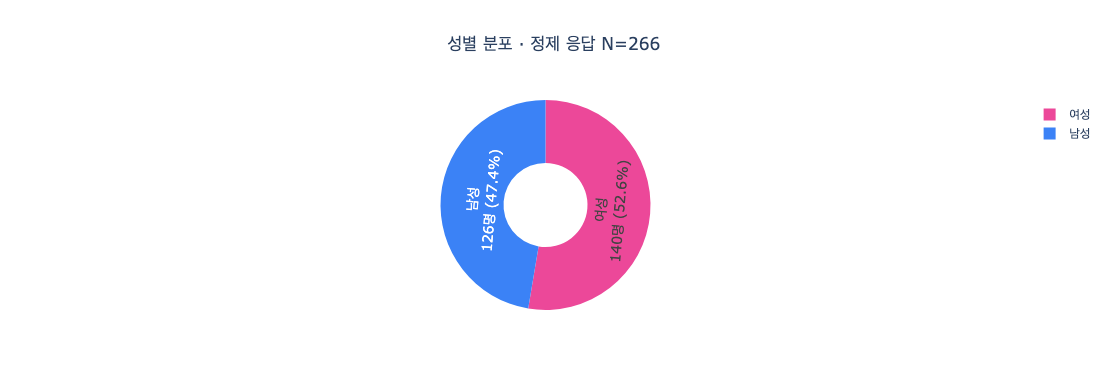

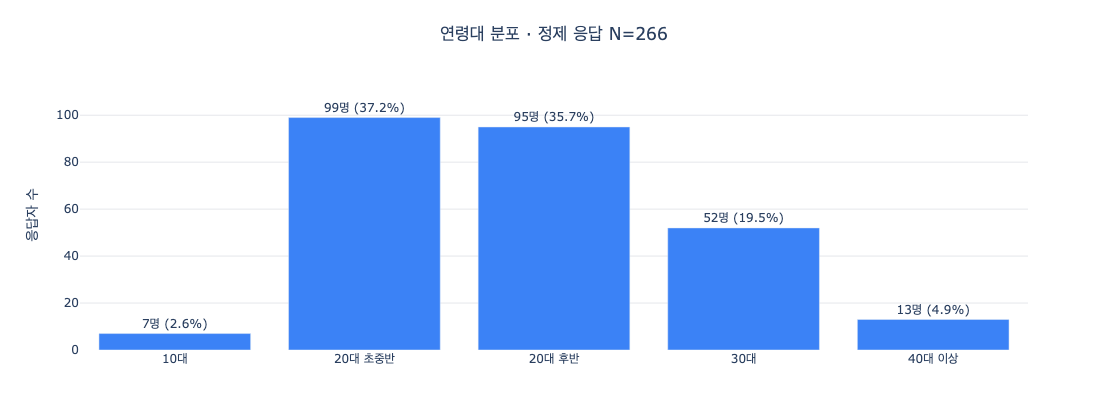

In [3]:
fig = go.Figure(go.Pie(
    labels=gender_counts['gender'], values=gender_counts['n'],
    marker_colors=['#EC4899', '#3B82F6'],
    texttemplate='%{label}<br>%{value}명 (%{percent})',
    textfont=dict(size=14), hole=0.4,
))
fig.update_layout(title=dict(text='성별 분포 · 정제 응답 N=266', x=0.5),
                  paper_bgcolor='white', height=390, width=800)
fig.show()

fig = go.Figure(go.Bar(
    x=age_counts['age'], y=age_counts['n'], marker_color='#3B82F6',
    text=[f'{int(count)}명 ({count/266:.1%})' for count in age_counts['n']],
    textposition='outside', cliponaxis=False,
))
fig.update_layout(title=dict(text='연령대 분포 · 정제 응답 N=266', x=0.5),
                  xaxis_title='', yaxis_title='응답자 수',
                  yaxis=dict(gridcolor='#E5E7EB', range=[0, 115]),
                  plot_bgcolor='white', paper_bgcolor='white',
                  height=420, width=900, margin=dict(t=80, b=70))
fig.show()

20대 초중반 99명과 20대 후반 95명을 합하면 **194/266명(72.9%)**이다. 이 표본은 20대 중심 편의표본이며 전체 패션 플랫폼 시장을 대표하는 확률표본이 아니다.

---
## 3. 패션 플랫폼 이용 현황

### 3-1. 플랫폼 사용 여부

Q5의 플랫폼 사용자는 정제 응답 266명 중 **200명(75.2%)**이다. 이후 추천 의향·지속 이용 의향 분석은 이 200명을 분모로 둔다.

In [4]:
platform_use = run('platform_use_distribution')
assert dict(zip(platform_use['uses_platform'], platform_use['n'])) == {'예': 200, '아니오': 66}
display(platform_use.rename(columns={'uses_platform':'사용 여부','n':'응답자 수','pct':'비율 (%)'}))

,사용 여부,응답자 수,비율 (%)
0,예,200,75.2
1,아니오,66,24.8


### 3-2. 주요 사용 플랫폼

02에서 Q6 플랫폼명을 표준화했다. 여기서는 쉼표·공백(`, `)으로 복수응답을 나눠 **플랫폼 사용자 200명**을 분모로 선택률을 계산한다. 복수 선택이므로 선택률 합계는 100%를 넘을 수 있다.

In [5]:
def split_multi_response(series, sep=', '):
    return series.dropna().str.split(sep).explode().str.strip()

def add_pct(count_series, denominator):
    return count_series.div(denominator).mul(100).round(1)

platform_base = run('platform_responses')
platform_user_n = int(population['platform_users'])
assert len(platform_base) == platform_user_n
assert platform_base['platforms'].notna().sum() == platform_user_n
platform_exploded = (
    split_multi_response(platform_base['platforms'])
    .value_counts().reset_index()
    .rename(columns={'platforms':'플랫폼', 'count':'언급 수'})
)
platform_exploded['선택률 (%)'] = add_pct(platform_exploded['언급 수'], platform_user_n)
expected_platforms = {
    '무신사':125, '에이블리':63, '지그재그':50, '종합 쇼핑몰':47,
    'KREAM':35, '29CM':21, '기타':10, '4910':7, '룩핀':2,
    'W컨셉':2, '자라':1, '쉬인':1,
}
assert dict(zip(platform_exploded['플랫폼'], platform_exploded['언급 수'])) == expected_platforms
display(platform_exploded)

,플랫폼,언급 수,선택률 (%)
0,무신사,125,62.5
1,에이블리,63,31.5
2,지그재그,50,25.0
3,종합 쇼핑몰,47,23.5
4,KREAM,35,17.5
5,29CM,21,10.5
6,기타,10,5.0
7,4910,7,3.5
8,룩핀,2,1.0
9,W컨셉,2,1.0


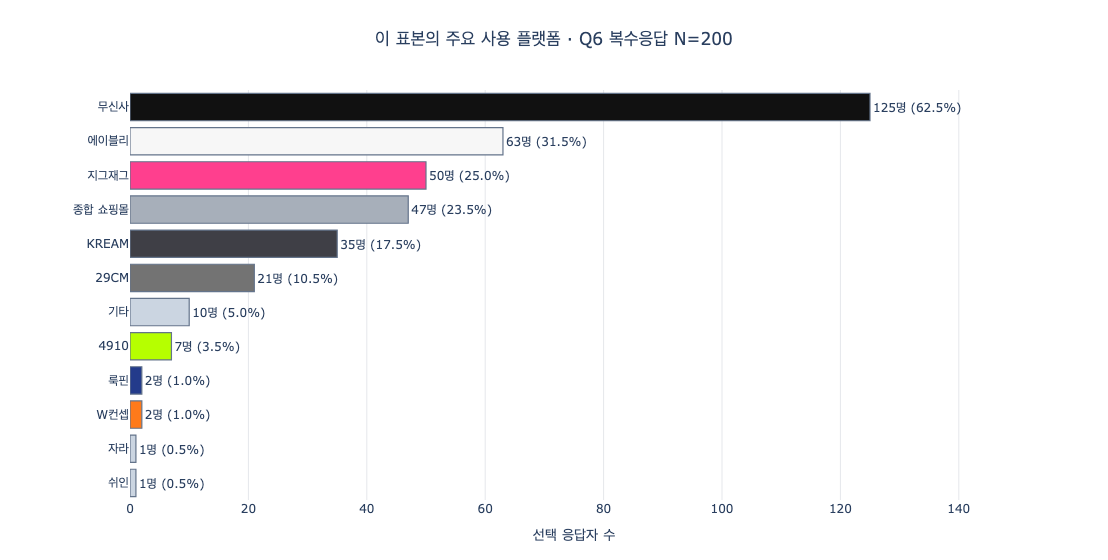

In [6]:
# 공식 BI 복제가 아닌 차트 구분용 근사색. 밝은 막대에는 외곽선을 둔다.
platform_colors = {
    '무신사':'#111111', '에이블리':'#F7F7F7', '지그재그':'#FF3F8E',
    '종합 쇼핑몰':'#A7AFBA', 'KREAM':'#3F3F46', '29CM':'#737373',
    '4910':'#B6FF00', '룩핀':'#233B8B', 'W컨셉':'#FF7A1A',
    '기타':'#CBD5E1',
}
fig = go.Figure(go.Bar(
    x=platform_exploded['언급 수'], y=platform_exploded['플랫폼'],
    orientation='h',
    marker_color=[platform_colors.get(name, '#CBD5E1') for name in platform_exploded['플랫폼']],
    marker_line_color='#64748B', marker_line_width=1.2,
    text=[f'{int(count)}명 ({pct:.1f}%)' for count,pct in zip(platform_exploded['언급 수'], platform_exploded['선택률 (%)'])],
    textposition='outside', cliponaxis=False,
))
fig.update_layout(
    title=dict(text='이 표본의 주요 사용 플랫폼 · Q6 복수응답 N=200', x=0.5),
    xaxis=dict(title='선택 응답자 수', gridcolor='#E5E7EB', range=[0, 150]),
    yaxis=dict(autorange='reversed'),
    plot_bgcolor='white', paper_bgcolor='white',
    width=1000, height=560, margin=dict(l=130, r=90, t=90, b=60),
)
fig.show()

무신사 125명(62.5%)이 가장 많이 포함됐고, 에이블리 63명(31.5%), 지그재그 50명(25.0%) 등이 뒤따랐다. 이는 **이 표본의 플랫폼 구성**이며 플랫폼별 성과나 시장점유율은 아니다.

---
## 4. 복수 플랫폼 이용 구조

Q6에서 표준화한 플랫폼명 개수를 쉼표 수로 계산하고, 2개 이상이면 복수 플랫폼 사용자로 분류한다. 자유입력 분리로 3개가 된 사례가 있어 정확한 앱 개수보다 **단일/복수** 구분만 사용한다.

In [7]:
multihoming = run('multihoming_distribution')
assert dict(zip(multihoming['platform_group'], multihoming['n'])) == {1:38, 2:162}
# SQL의 쉼표 개수 기준을 복수응답 분리 결과와 대조한다.
response_platform_count = platform_base['platforms'].str.split(', ').str.len()
assert int(response_platform_count.ge(2).sum()) == 162
multihoming['구분'] = multihoming['platform_group'].map({1:'단일 플랫폼', 2:'복수 플랫폼'})
display(multihoming[['구분','n','pct']].rename(columns={'n':'응답자 수','pct':'비율 (%)'}))

,구분,응답자 수,비율 (%)
0,단일 플랫폼,38,19.0
1,복수 플랫폼,162,81.0


플랫폼 사용자 중 **162/200명(81.0%)**이 2개 이상을 선택했다. 상당수가 하나의 플랫폼만 이용하지 않는 표본이라는 뜻이다. 이 분포만으로는 이탈·충성도나 시장 전체 구조까지 설명하기 어렵다.

---
## 5. 플랫폼을 선택하는 기준

Q7은 최대 3개를 고르는 복수응답이다. `', '` 분리·`explode`·응답자 기준 비율을 사용한다.

In [8]:
factor_base = run('selection_factor_responses')
assert len(factor_base) == 200
selection_factor_base_n = int(factor_base['selection_factors'].notna().sum())
assert selection_factor_base_n == 200
factors_exploded = (
    factor_base['selection_factors'].dropna()
    .str.split(', ').explode().str.strip().value_counts().reset_index()
    .rename(columns={'selection_factors':'선택 요소', 'count':'언급 수'})
)
expected_factors = {
    '가격 / 할인 혜택':169, '브랜드 및 상품 다양성':112,
    '리뷰 / 후기 신뢰도':88, '앱 사용 편의성 (UI/UX)':59,
    '나에게 맞는 스타일 추천':50, '배송 속도 및 편리성':21,
    '적립금 / 멤버십 혜택':20,
}
assert dict(zip(factors_exploded['선택 요소'], factors_exploded['언급 수'])) == expected_factors
factors_exploded['선택률 (%)'] = add_pct(factors_exploded['언급 수'], selection_factor_base_n)
display(factors_exploded)

,선택 요소,언급 수,선택률 (%)
0,가격 / 할인 혜택,169,84.5
1,브랜드 및 상품 다양성,112,56.0
2,리뷰 / 후기 신뢰도,88,44.0
3,앱 사용 편의성 (UI/UX),59,29.5
4,나에게 맞는 스타일 추천,50,25.0
5,배송 속도 및 편리성,21,10.5
6,적립금 / 멤버십 혜택,20,10.0


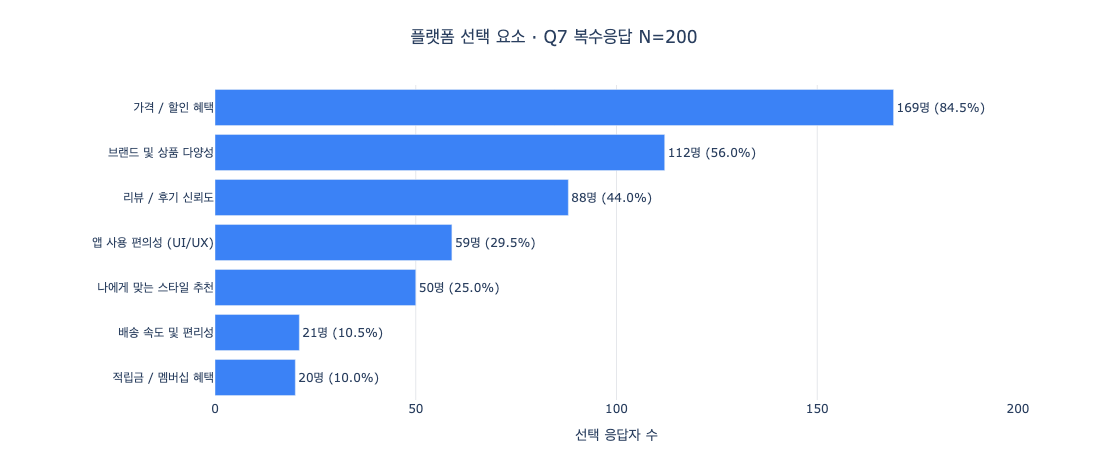

In [9]:
fig = go.Figure(go.Bar(
    x=factors_exploded['언급 수'], y=factors_exploded['선택 요소'],
    orientation='h', marker_color='#3B82F6',
    text=[f'{int(count)}명 ({pct:.1f}%)' for count,pct in zip(factors_exploded['언급 수'], factors_exploded['선택률 (%)'])],
    textposition='outside', cliponaxis=False,
))
fig.update_layout(
    title=dict(text='플랫폼 선택 요소 · Q7 복수응답 N=200', x=0.5),
    xaxis=dict(title='선택 응답자 수', gridcolor='#E5E7EB', range=[0, 200]),
    yaxis=dict(autorange='reversed'), plot_bgcolor='white', paper_bgcolor='white',
    width=1000, height=460, margin=dict(l=215, r=90, t=85, b=60),
)
fig.show()

가격·할인 혜택 169명, 브랜드 및 상품 다양성 112명, 리뷰·후기 신뢰도 88명 순으로 많이 선택됐다. 전체 **7개 항목**을 표시했으며, 한 사람이 여러 항목을 골랐으므로 비율 합계는 100%를 넘는다.

---
## 6. 플랫폼을 여는 목적

Q8은 최대 2개를 고르는 복수응답이다. **응답자 200명**을 분모로 둔다.

In [10]:
purpose_base = run('open_purpose_responses')
assert len(purpose_base) == 200
open_purpose_base_n = int(purpose_base['open_purpose'].notna().sum())
assert open_purpose_base_n == 200
purpose_exploded = (
    purpose_base['open_purpose'].dropna()
    .str.split(', ').explode().str.strip().value_counts().reset_index()
    .rename(columns={'open_purpose':'오픈 목적', 'count':'언급 수'})
)
expected_purposes = {
    '특정 상품을 구매하기 위해':125,
    '그냥 구경하기 위해 (윈도우 쇼핑)':115,
    '스타일 아이디어를 얻기 위해':57,
    '할인 또는 특가 확인':55,
    '특정 브랜드 신상품 확인':12,
}
assert dict(zip(purpose_exploded['오픈 목적'], purpose_exploded['언급 수'])) == expected_purposes
purpose_exploded['선택률 (%)'] = add_pct(purpose_exploded['언급 수'], open_purpose_base_n)
display(purpose_exploded)

,오픈 목적,언급 수,선택률 (%)
0,특정 상품을 구매하기 위해,125,62.5
1,그냥 구경하기 위해 (윈도우 쇼핑),115,57.5
2,스타일 아이디어를 얻기 위해,57,28.5
3,할인 또는 특가 확인,55,27.5
4,특정 브랜드 신상품 확인,12,6.0


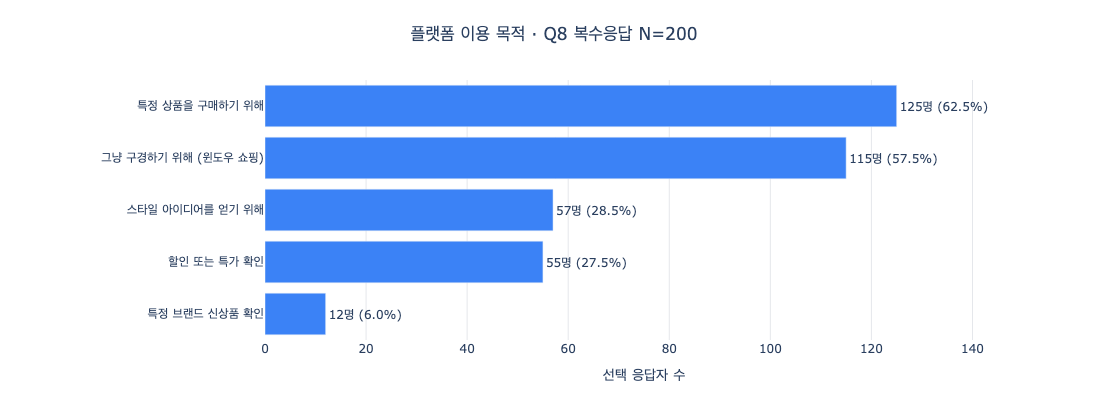

In [11]:
fig = go.Figure(go.Bar(
    x=purpose_exploded['언급 수'], y=purpose_exploded['오픈 목적'],
    orientation='h', marker_color='#3B82F6',
    text=[f'{int(count)}명 ({pct:.1f}%)' for count,pct in zip(purpose_exploded['언급 수'], purpose_exploded['선택률 (%)'])],
    textposition='outside', cliponaxis=False,
))
fig.update_layout(
    title=dict(text='플랫폼 이용 목적 · Q8 복수응답 N=200', x=0.5),
    xaxis=dict(title='선택 응답자 수', gridcolor='#E5E7EB', range=[0, 150]),
    yaxis=dict(autorange='reversed'), plot_bgcolor='white', paper_bgcolor='white',
    width=1000, height=400, margin=dict(l=265, r=85, t=80, b=60),
)
fig.show()

특정 상품 구매 125명뿐 아니라 구경 115명, 스타일 아이디어 57명, 할인·특가 확인 55명도 선택됐다. 이 표본의 플랫폼 이용 목적에는 구매와 탐색이 함께 포함된다. 이 문항은 이용 목적에 대한 응답이며 실제 구매 행동과는 다르다.

---
## 7. 분석에 사용한 주요 문항

원본 Google Forms 설문 문항을 분석 역할별로 묶었다. 아래는 분석에 사용한 문항의 역할과 응답 형태를 요약한 것이다.

| 역할 | 문항 | 데이터 형태 |
|---|---|---|
| 응답자 특성 | Q1 성별, Q2 연령, Q3 패션 콘텐츠 탐색 빈도, Q4 월평균 패션 지출 | Q3·Q4 순서형 |
| 플랫폼 이용 | Q5 사용 여부, Q6 주 이용 플랫폼, Q7 선택 기준, Q8 이용 목적 | Q6 복수응답(1–2개), Q7 최대 3개, Q8 최대 2개 |
| 자기보고 구매 활동 | Q9 최근 6개월 구매 빈도, Q10 최근 구매 시점, Q11 1회 평균 지출, Q12 재구매 이유 | Q9·Q10 순서형, Q12 최대 2개 |
| 태도와 불편 | Q13 불만 경험, Q14 지속 이용 의향, Q15 추천 의향 | Q13 복수응답, Q14 5단계, Q15 0–10점 |
| 채널 | Q16 최초 인지 경로, Q17 최근 구매 영향 채널 | 단일응답 |
| 자유응답 | Q18 사용 중 아쉬웠던 점 | 선택 응답 자유서술 |

---
## 8. 주요 변수와 코딩

04가 사용하는 변수 정의만 적는다. H1·H2의 분류와 점수 방향은 02가 생성한 [분석용 SQL 뷰](../sql/02_data_preparation.sql)를 따른다. Q16·Q17의 비교 라벨은 [04 SQL](../sql/04_eda_validation.sql)에서 정의한다.

| 변수 | 원문·기준 | 현재 분석의 코딩 |
|---|---|---|
| 추천 의향(Q15) | 0–10점 원점수 | 비추천자 0–6, 중립 7–8, 추천자 9–10 |
| 지속 이용 의향(Q14) | 5단계 응답 | 다른 앱으로 바꿀 것 같다=1 → 계속 사용할 것 같다=5. ‘아마 사용할 것 같다’·‘계속 사용할 것 같다’를 긍정으로 분류 |
| 자기보고 구매 빈도(Q9) | 최근 6개월 구매 | 구매자에서 1–2번=1, 3–5번=2, 6번 이상=3 |
| 자기보고 구매 최근성(Q10) | 가장 최근 구매 시점 | 6개월 이상=1, 3–6개월=2, 1–3개월=3, 1개월 이내=4. 높을수록 최근 구매 시점이 가까움 |
| 최초 인지 채널(Q16) | 단일응답 | 보조 H3의 기준 채널. SNS·유튜브·친구/지인 인지자만 동일 채널 여부 비교 |
| 최근 구매 영향 채널(Q17) | 단일응답 | Q16과 표준화 채널명이 같은지 비교 |
| 선택형 불편(Q13) | 복수응답 | 사용자별 선택 항목을 `', '`로 분리하고 항목별 응답자 수 집계 |
| 자유응답(Q18) | 유효 응답 92건 | 확정 라벨 CSV(`data/q18_audited_labels.csv`)의 다중 라벨을 02에서 1:1 병합해 MySQL에 적재 |

---
## 9. 분석별 모집단

문항의 응답 대상과 유효 응답 범위가 달라 04의 분모도 달라진다.

In [12]:
validity = run('variable_validity').iloc[0]
assert validity.to_dict() == {
    'q15_n':200, 'q14_n':200, 'q9_buyer_n':191, 'q10_buyer_n':191,
    'q13_n':200, 'q18_n':92, 'q18_user_n':68, 'h3_channel_n':155,
}, validity.to_dict()
analysis_bases = pd.DataFrame([
    ['추천 의향·지속 이용 의향', '플랫폼 사용자', int(validity['q15_n'])],
    ['자기보고 구매 빈도·최근성', '최근 6개월 구매자', int(validity['q9_buyer_n'])],
    ['보조 H3 · 동일 채널 응답', 'Q16이 SNS·유튜브·친구/지인인 플랫폼 사용자', int(validity['h3_channel_n'])],
    ['Q13 선택형 불편', '플랫폼 사용자', int(validity['q13_n'])],
    ['Q18 자유응답 전체', '유효 자유응답', int(validity['q18_n'])],
    ['Q18 중 플랫폼 사용자', '유효 자유응답 중 플랫폼 사용자', int(validity['q18_user_n'])],
], columns=['분석', '기준 집단', 'N'])
display(analysis_bases)

,분석,기준 집단,N
0,추천 의향·지속 이용 의향,플랫폼 사용자,200
1,자기보고 구매 빈도·최근성,최근 6개월 구매자,191
2,보조 H3 · 동일 채널 응답,Q16이 SNS·유튜브·친구/지인인 플랫폼 사용자,155
3,Q13 선택형 불편,플랫폼 사용자,200
4,Q18 자유응답 전체,유효 자유응답,92
5,Q18 중 플랫폼 사용자,유효 자유응답 중 플랫폼 사용자,68


---
## 10. 데이터 해석 범위

- Google Forms로 직접 수집한 설문이며, **20대 194/266명(72.9%)** 이 포함된 편의표본이다.
- 여러 패션 플랫폼 이용자가 포함됐다. 플랫폼 사용자 중 **162/200명(81.0%)** 이 복수 플랫폼을 선택했으며, 특정 플랫폼 하나의 고객 만족도 조사는 아니다.
- 구매와 지속 이용은 실제 서비스 로그가 아닌 **자기보고 구매 활동·이용 의향**이다.
- Q6·Q7·Q8·Q13은 복수응답이므로 항목별 비율의 합계가 100%를 넘을 수 있다.
- Q18은 자발적으로 답한 92건이다. Q18의 언급률은 전체 사용자 불만율이 아니다.

이 범위를 전제로 [04 EDA·검증](04_eda_validation.ipynb)의 H1/H2·보조 H3와 후속 탐색을 읽는다.